In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 8** — 8D Black-Box Optimisation

Optimising an eight-dimensional black-box function representing e.g. ML model validation accuracy across eight hyperparameters.

- **Optimisation Goal:** Maximise
- **Input:** 8D
- **All-time best:** 9.951 at [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476] (Week 3)

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 8
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy')

# New data for Week 8 (Function 8)
X_w7_new_point = np.array([0.097603, 0.135405, 0.156089, 0.022873, 0.887585, 0.187209, 0.032006, 0.531620], dtype=np.float64)
Y_w7_new_point = np.array([9.8229869865595], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w7_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w7_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 8: ", X_unique)
print("Updated Outputs (Y) - Function 8: ", Y_updated)

Updated Inputs (X) - Function 8:  [[0.007838   0.337307   0.164679   0.407388   0.632409   0.551169
  0.306982   0.5023    ]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.02894663 0.02827906 0.48137155 0.6131746  0.67266045 0.02211341
  0.6014833  0.52488505]
 [0.029788   0.370437   0.009211   0.56322    0.914458   0.813905
  0.149129   0.554138  ]
 [0.0417     0.167136   0.185989   0.004377   0.961301   0.357272
  0.961301   0.357272  ]
 [0.04432925 0.01358149 0.25819824 0.57764416 0.05127992 0.15856307
  0.59103012 0.07795293]
 [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
  0.48830701 0.89308498]
 [0.097603   0.135405   0.156089   0.022873   0.887585   0.187209
  0.032006   0.53162   ]
 [0.110613   0.166799   0.129222   0.228937   0.996353   0.475272
  0.30197    0.476277  ]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  0.92123758 0.67475276]
 [0.117464   0.226763   0.160734   0.103849   

## Output Analysis

- Last week (w6) I got the result of 9.704 and this week I saw my all-time best of 9.823.

- **Real-World Implication:** A solid positive trend — 9.704 → 9.823 is a meaningful step toward the w3 best of 9.951. 
    - The stochastic nature of this function means small, consistent improvements are the best we can realistically hope for each week.

- **Model Clues:** Comparing w7 [0.098, 0.135, 0.156, 0.023, 0.888, 0.187, 0.032, 0.532] to the w3 best [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476], the most significant gap is x5 (0.888 vs 0.996) and x6 (0.187 vs 0.475). 
    - x5 in particular has been the strongest signal across the entire history — all top results had x5 above 0.94, and the w3 best had x5=0.996.

- **Key change for w8:** Tighten focused grid to std=0.02 centred on the w3 best, with particular attention to keeping x5 near 0.996. 
    - Retain 30% uniform component given the stochastic noise.

## Bayesian Optimisation — Gaussian Process Regressor

- **Model:** ConstantKernel × Matern (nu=2.5, ARD 8D) + WhiteKernel (noise_level=1e-3) with Yeo-Johnson output transformation.

- **Changes for w8:**
    - WhiteKernel noise_level kept at 1e-3 (higher than other functions) — this function is explicitly described as stochastic and the higher noise floor prevents overfitting to random fluctuations.

    - Yeo-Johnson transformation retained.

    - n_restarts_optimizer=25 maintained.
    
    - **Intended impact:** Use 7 weeks of data to sharpen the ARD length scales and identify which of the 8 dimensions (especially x5) most reliably predict high output.

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(
    Y_updated.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

# ARD Matern 2.5 with higher WhiteKernel for stochastic noise
kernel = C(1.0) * Matern(length_scale=[0.1]*8, nu=2.5) + \
         WhiteKernel(noise_level=1e-3)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)
print('\nFitted kernel:', model.kernel_)

# Print fitted ARD length scales for dimension sensitivity analysis
fitted_params = model.kernel_.get_params()
print('\nARD length scales (shorter = more sensitive):')
for k, v in fitted_params.items():
    if 'length_scale' in k and not 'bounds' in k:
        print(f'  {k}: {v}')

Original Y:    [9.83756547 8.45948162 8.83074505 9.61655465 8.76386781 9.01307515
 9.598482   9.82298699 9.95104443 7.85454099 9.87247349 8.97655402
 9.14163949 6.45194313 7.00522736 9.34427428 9.70409915 8.81755844
 7.13162397 8.60611679 7.92375877 8.2780624  7.69236805 8.47293632
 9.18300525 8.28400781 8.04221254 8.42175924 7.29987205 7.3987211
 7.43374407 6.76796253 7.95787474 7.3790829  7.31089382 8.54174792
 6.79198578 7.43659353 7.46087219 7.97768459 8.15998319 5.84106731
 7.32743458 6.88784639 6.40258841 5.59219339 7.11345716]
Transformed Y: [ 1.61947849  0.32094759  0.66541548  1.40762148  0.60306564  0.83606196
  1.39035674  1.60546267  1.72877495 -0.23145078  1.65306271  0.80180418
  0.95696311 -1.46715254 -0.9875298   1.14847407  1.49137991  0.65311125
 -0.87650081  0.45651325 -0.16881533  0.15411423 -0.37761301  0.33335991
  0.99596355  0.15956591 -0.06128044  0.28617657 -0.72788667 -0.64013994
 -0.60897436 -1.19449451 -0.13788873 -0.65759779 -0.71811862  0.39692487
 -1.173

/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 4/Week Function Analysis/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 4/Week Function Analysis/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.

## **Acquisition Function**: UCB (beta=2.0) with Tight Focused Grid (std=0.02)

- **Strategy:** UCB with beta=2.0 maintained as it is appropriate for a stochastic function where some exploration is always needed.

- **Key change for w8:** Tighten focused grid to std=0.02 (from 0.05 in w7), centred on the w3 all-time best [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476]. 
    - A 70/30 focused/uniform split as larger uniform component than other functions because the stochastic nature means we cannot fully rule out a better peak elsewhere.

- **Intended impact:** Surpass 9.951 and set a new all-time best by precisely targeting x5≈0.996 with all other dimensions close to the w3 profile.

In [4]:
def upper_confidence_bound(X, model, beta=2.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

# Tight focused grid centred on W3 all-time best
w3_best = np.array([0.110613, 0.166799, 0.129222, 0.228937, 0.996353, 0.475272, 0.301970, 0.476277])

x_focused = np.clip(
    np.random.normal(loc=w3_best, scale=0.02, size=(140000, 8)),
    0.000001, 0.999999
)
x_uniform = np.random.uniform(0.000001, 0.999999, (60000, 8))
x_grid = np.vstack([x_focused, x_uniform])

ucb_values = upper_confidence_bound(x_grid, model, beta=2.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f'W3 best coordinates: {w3_best}')
print(f'Strategic Week 8 Query (Function 8): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}-{next_query[6]:.6f}-{next_query[7]:.6f}')

W3 best coordinates: [0.110613 0.166799 0.129222 0.228937 0.996353 0.475272 0.30197  0.476277]
Strategic Week 8 Query (Function 8): 0.014565-0.233424-0.156410-0.215734-0.993571-0.163832-0.082661-0.956290


## **Visualisation**: Optimisation Progress and Dimension Sensitivity

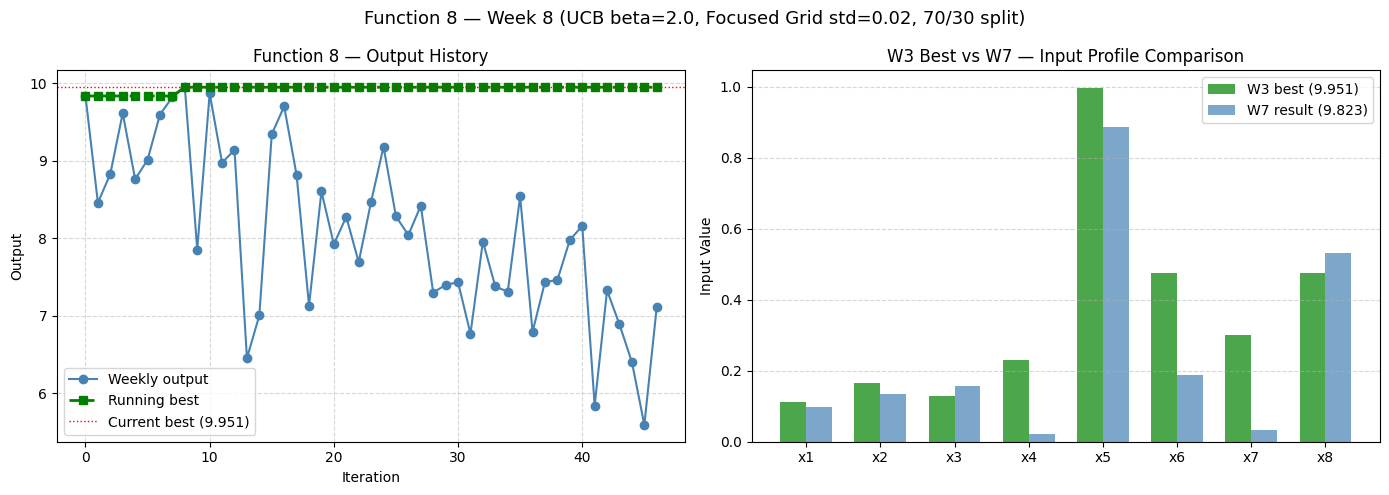

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(np.max(Y_updated), color='red', linestyle=':', linewidth=1, label=f'Current best ({np.max(Y_updated):.3f})')
axes[0].set_title('Function 8 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Compare W3 best vs W7 input profiles
dim_labels = [f'x{i+1}' for i in range(8)]
x_pos = np.arange(8)
width = 0.35
axes[1].bar(x_pos - width/2, w3_best, width, label='W3 best (9.951)', color='green', alpha=0.7)
axes[1].bar(x_pos + width/2, X_w7_new_point, width, label='W7 result (9.823)', color='steelblue', alpha=0.7)
axes[1].set_title('W3 Best vs W7 — Input Profile Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(dim_labels)
axes[1].set_ylabel('Input Value')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 8 — Week 8 (UCB beta=2.0, Focused Grid std=0.02, 70/30 split)', fontsize=13)
plt.tight_layout()
plt.show()